# Installing required packages

If you don't already have the following packages installed, uncomment the following lines and run the cell to install them. The required packages are: `pandas`, `numpy`, `seaborn`, `matplotlib`, `datasets`, `transformers`, `scikit-learn`, `tqdm`, and `torch`.

In [2]:
# ! pip install pandas
# ! pip install numpy
# ! pip install seaborn
# ! pip install matplotlib
# ! pip install datasets
# ! pip install transformers
# ! pip install scikit-learn
# ! pip install tqdm
# ! pip install torch

First we need to load any necessary packages

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from datasets import load_dataset
from transformers import logging, pipeline

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

import time
from tqdm.auto import tqdm
import warnings


# Model Fitting

We will load the first dataset, Jigsaw, for building and training the logistic regression model. For this project, the dataset needs to be split into 3 parts: a 10,000 observation evaluation dataset, a 10,000 observation threshold dataset for Toxic-BERT, and the remaining data is used to train the logistic regression.

In [4]:
jigsaw = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

train_df = jigsaw['train'].to_pandas()

summary_table = pd.DataFrame({
    'count': [train_df['toxic'].sum()],
    'proportion': [train_df['toxic'].mean()]
})

summary_table

,count,proportion
0,15294,0.095844


In [5]:
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
full_df = train_df.copy()

# final held-out evaluation set
train_pool_df, final_eval_df = train_test_split(
    full_df,
    test_size=10000,
    stratify=full_df["toxic"],
    random_state=507
)

train_pool_df = train_pool_df.reset_index(drop=True)
final_eval_df = final_eval_df.reset_index(drop=True)

# separate threshold set for BERT
train_main_df, bert_thresh_df = train_test_split(
    train_pool_df,
    test_size=10000,
    stratify=train_pool_df["toxic"],
    random_state=508
)

train_main_df = train_main_df.reset_index(drop=True)
bert_thresh_df = bert_thresh_df.reset_index(drop=True)

Building the logistic regression model

In [7]:
pipeline_logistic = Pipeline([
     ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 3))),
     ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced'))
 ])

This code chunk splits the training data in to five subsets for cross-validation training

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=507)

Assessing model fit

In [9]:
scores = cross_val_score(
    pipeline_logistic,
    train_pool_df['comment_text'],
    train_pool_df['toxic'],
    cv=cv,
    scoring='roc_auc'   
)

print("AUC scores:", scores)
print("Mean AUC:", scores.mean())

AUC scores: [0.96326223 0.9650933  0.96415805 0.96489874 0.96209322]
Mean AUC: 0.9639011073515249


Training the final logistic regression model on the full Jigsaw dataset (except for the evaluation subset)

In [10]:
pipeline_logistic.fit(train_pool_df['comment_text'], train_pool_df['toxic'])

,steps,"[('tfidf', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [55]:
feature_names = pipeline_logistic.named_steps['tfidf'].get_feature_names_out()

n_unigrams = sum(' ' not in f for f in feature_names)
n_bigrams = sum(f.count(' ') == 1 for f in feature_names)
n_trigrams = sum(f.count(' ') == 2 for f in feature_names)

print("Unigrams:", n_unigrams)
print("Bigrams:", n_bigrams)
print("Trigrams:", n_trigrams)

Unigrams: 6430
Bigrams: 2359
Trigrams: 1211


Threshold fine tuning is performed by identifying the best F1 threshold which balances recall and precision. Thresholds across a range from .01 to .99 were considered.

In [56]:
y_true = train_pool_df['toxic']

y_probs_cv = cross_val_predict(
    pipeline_logistic,
    train_pool_df['comment_text'],
    y_true,
    cv=cv,
    method='predict_proba'
)[:, 1]

In [57]:
thresholds = np.linspace(0.01, 0.99, 100)

f1_list = []

for t in thresholds:
    y_pred_t = (y_probs_cv >= t).astype(int)
    f1_list.append(f1_score(y_true, y_pred_t, zero_division=0))

In [58]:

best_idx = np.argmax(f1_list)
best_threshold = thresholds[best_idx]

print("Best F1 threshold:", best_threshold)
print("Best F1:", f1_list[best_idx])

Best F1 threshold: 0.7722222222222221
Best F1: 0.7576468862319372


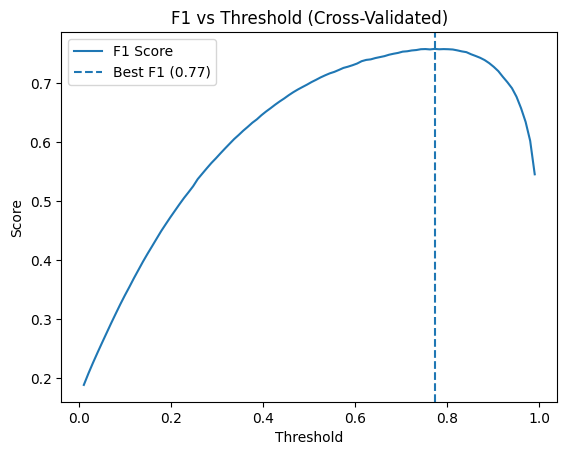

In [59]:
plt.plot(thresholds, f1_list, label="F1 Score")
plt.axvline(best_threshold, linestyle='--', label=f'Best F1 ({best_threshold:.2f})')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 vs Threshold (Cross-Validated)")
plt.legend()

plt.show()

Now that we have trained the logistic regression, we want to load Toxic-BERT from HuggingFace as a comparison. We use the Hugging Face Transformers pipeline API to load the pre-trained Toxic-BERT model and its tokenizer for text classification. It creates a ready-to-use function that takes raw text as input and returns predicted class probabilities (toxicity scores) for each label.

In [60]:
logging.set_verbosity_error()

bert_pipe = pipeline(
        "text-classification",
        model="unitary/toxic-bert",
        top_k = None
    )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10452.35it/s]


Note: the Toxic BERT threshold is calculated from a subset of 10,000 of the training observations to greatly reduce computational load. This still provides a solid understanding of Toxic BERT's performance and classification behavior on the Jigsaw data. Batching is used in the code below and subsequent chunks to further reduce computational load by splitting the dataset into many smaller subsets.

The code currently uses a saved cache from GitHub to reduce computation time. To run the code directly, users can change "use_saved_results = True" to False.

In [ ]:
use_saved_results = True

github_url = "https://raw.githubusercontent.com/enoracat/Stats_507_Final_Project/main/bert_thresh_res.pkl"

if use_saved_results == True:
    bert_thresh_res = pd.read_pickle(github_url)

else:
    warnings.filterwarnings("ignore")

    bert_thresh_df_copy = bert_thresh_df.copy()
    bert_thresh_df_copy["text"] = bert_thresh_df_copy["comment_text"].fillna("").astype(str)

    def score_texts(texts, batch_size=8):
        results = []
        start = time.time()

        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]

            batch_results = bert_pipe(
                batch,
                batch_size=batch_size,
                truncation=True,
                max_length=512
            )

            results.extend(batch_results)

            if i % (batch_size * 20) == 0:
                print(f"Processed {i} / {len(texts)} in {time.time() - start:.1f} seconds")

        return results

    bert_thresh_df_results = score_texts(bert_thresh_df_copy["text"].tolist())

    bert_thresh_res_df = pd.DataFrame(
        [{f'bert_{item["label"]}': item["score"] for item in row} for row in bert_thresh_df_results]
    )

    bert_thresh_res = pd.concat([bert_thresh_df_copy.reset_index(drop=True), bert_thresh_res_df], axis=1)

    bert_thresh_res.to_pickle("bert_thresh_res.pkl")

  0%|          | 1/1250 [00:00<05:35,  3.72it/s]

Processed 0 / 10000 in 0.3 seconds


  2%|▏         | 21/1250 [00:10<06:33,  3.12it/s]

Processed 160 / 10000 in 10.7 seconds


  3%|▎         | 41/1250 [00:24<11:24,  1.77it/s]

Processed 320 / 10000 in 24.9 seconds


  5%|▍         | 61/1250 [00:37<11:09,  1.78it/s]

Processed 480 / 10000 in 37.1 seconds


  6%|▋         | 81/1250 [00:48<11:13,  1.74it/s]

Processed 640 / 10000 in 48.9 seconds


  8%|▊         | 101/1250 [01:01<12:57,  1.48it/s]

Processed 800 / 10000 in 61.6 seconds


 10%|▉         | 121/1250 [01:16<16:26,  1.14it/s]

Processed 960 / 10000 in 76.1 seconds


 11%|█▏        | 141/1250 [01:30<09:21,  1.98it/s]

Processed 1120 / 10000 in 90.6 seconds


 13%|█▎        | 161/1250 [01:44<13:27,  1.35it/s]

Processed 1280 / 10000 in 104.8 seconds


 14%|█▍        | 181/1250 [02:00<17:46,  1.00it/s]

Processed 1440 / 10000 in 120.2 seconds


 16%|█▌        | 201/1250 [02:13<10:42,  1.63it/s]

Processed 1600 / 10000 in 133.7 seconds


 18%|█▊        | 221/1250 [02:28<13:43,  1.25it/s]

Processed 1760 / 10000 in 148.5 seconds


 19%|█▉        | 241/1250 [02:43<16:01,  1.05it/s]

Processed 1920 / 10000 in 163.8 seconds


 21%|██        | 261/1250 [02:58<09:30,  1.73it/s]

Processed 2080 / 10000 in 178.3 seconds


 22%|██▏       | 281/1250 [03:12<13:24,  1.20it/s]

Processed 2240 / 10000 in 192.5 seconds


 24%|██▍       | 301/1250 [03:26<12:20,  1.28it/s]

Processed 2400 / 10000 in 206.8 seconds


 26%|██▌       | 321/1250 [03:43<09:17,  1.67it/s]

Processed 2560 / 10000 in 223.2 seconds


 27%|██▋       | 341/1250 [03:58<07:55,  1.91it/s]

Processed 2720 / 10000 in 238.4 seconds


 29%|██▉       | 361/1250 [04:13<11:29,  1.29it/s]

Processed 2880 / 10000 in 253.5 seconds


 30%|███       | 381/1250 [04:28<12:46,  1.13it/s]

Processed 3040 / 10000 in 268.6 seconds


 32%|███▏      | 401/1250 [04:47<09:41,  1.46it/s]

Processed 3200 / 10000 in 287.4 seconds


 34%|███▎      | 421/1250 [04:59<07:10,  1.93it/s]

Processed 3360 / 10000 in 299.0 seconds


 35%|███▌      | 441/1250 [05:13<06:40,  2.02it/s]

Processed 3520 / 10000 in 314.0 seconds


 37%|███▋      | 461/1250 [05:29<10:34,  1.24it/s]

Processed 3680 / 10000 in 329.9 seconds


 38%|███▊      | 481/1250 [05:44<13:47,  1.08s/it]

Processed 3840 / 10000 in 344.3 seconds


 40%|████      | 501/1250 [05:58<10:37,  1.18it/s]

Processed 4000 / 10000 in 358.3 seconds


 42%|████▏     | 521/1250 [06:12<09:14,  1.31it/s]

Processed 4160 / 10000 in 372.8 seconds


 43%|████▎     | 541/1250 [06:27<06:34,  1.80it/s]

Processed 4320 / 10000 in 387.8 seconds


 45%|████▍     | 561/1250 [06:38<04:11,  2.74it/s]

Processed 4480 / 10000 in 398.5 seconds


 46%|████▋     | 581/1250 [06:48<07:45,  1.44it/s]

Processed 4640 / 10000 in 408.7 seconds


 48%|████▊     | 601/1250 [07:01<07:09,  1.51it/s]

Processed 4800 / 10000 in 421.5 seconds


 50%|████▉     | 621/1250 [07:15<06:41,  1.57it/s]

Processed 4960 / 10000 in 435.6 seconds


 51%|█████▏    | 642/1250 [07:27<04:00,  2.53it/s]

Processed 5120 / 10000 in 447.0 seconds


 53%|█████▎    | 661/1250 [07:39<07:47,  1.26it/s]

Processed 5280 / 10000 in 459.3 seconds


 54%|█████▍    | 681/1250 [07:53<08:02,  1.18it/s]

Processed 5440 / 10000 in 473.2 seconds


 56%|█████▌    | 701/1250 [08:07<04:53,  1.87it/s]

Processed 5600 / 10000 in 487.1 seconds


 58%|█████▊    | 721/1250 [08:20<04:58,  1.77it/s]

Processed 5760 / 10000 in 500.1 seconds


 59%|█████▉    | 741/1250 [08:32<04:13,  2.01it/s]

Processed 5920 / 10000 in 512.3 seconds


 61%|██████    | 762/1250 [08:45<06:08,  1.32it/s]

Processed 6080 / 10000 in 525.4 seconds


 62%|██████▏   | 781/1250 [08:56<05:36,  1.39it/s]

Processed 6240 / 10000 in 536.3 seconds


 64%|██████▍   | 801/1250 [09:07<05:08,  1.45it/s]

Processed 6400 / 10000 in 547.9 seconds


 66%|██████▌   | 821/1250 [09:23<06:18,  1.13it/s]

Processed 6560 / 10000 in 563.6 seconds


 67%|██████▋   | 842/1250 [09:36<03:20,  2.03it/s]

Processed 6720 / 10000 in 576.0 seconds


 69%|██████▉   | 861/1250 [09:48<02:53,  2.24it/s]

Processed 6880 / 10000 in 589.0 seconds


 70%|███████   | 881/1250 [10:04<03:38,  1.69it/s]

Processed 7040 / 10000 in 604.4 seconds


 72%|███████▏  | 901/1250 [10:20<03:05,  1.88it/s]

Processed 7200 / 10000 in 620.2 seconds


 74%|███████▎  | 921/1250 [10:32<04:41,  1.17it/s]

Processed 7360 / 10000 in 633.0 seconds


 75%|███████▌  | 941/1250 [10:46<04:50,  1.06it/s]

Processed 7520 / 10000 in 646.8 seconds


 77%|███████▋  | 961/1250 [10:58<03:25,  1.41it/s]

Processed 7680 / 10000 in 658.3 seconds


 78%|███████▊  | 981/1250 [11:11<03:05,  1.45it/s]

Processed 7840 / 10000 in 671.3 seconds


 80%|████████  | 1001/1250 [11:27<02:15,  1.83it/s]

Processed 8000 / 10000 in 687.0 seconds


 82%|████████▏ | 1021/1250 [11:39<01:19,  2.87it/s]

Processed 8160 / 10000 in 699.2 seconds


 83%|████████▎ | 1041/1250 [11:52<01:32,  2.26it/s]

Processed 8320 / 10000 in 712.2 seconds


 85%|████████▍ | 1061/1250 [12:03<02:04,  1.52it/s]

Processed 8480 / 10000 in 723.9 seconds


 86%|████████▋ | 1081/1250 [12:17<01:44,  1.61it/s]

Processed 8640 / 10000 in 737.4 seconds


 88%|████████▊ | 1101/1250 [12:34<02:01,  1.23it/s]

Processed 8800 / 10000 in 754.7 seconds


 90%|████████▉ | 1121/1250 [12:51<01:49,  1.18it/s]

Processed 8960 / 10000 in 771.8 seconds


 91%|█████████▏| 1141/1250 [13:05<01:31,  1.20it/s]

Processed 9120 / 10000 in 785.7 seconds


 93%|█████████▎| 1161/1250 [13:18<01:01,  1.45it/s]

Processed 9280 / 10000 in 798.4 seconds


 94%|█████████▍| 1181/1250 [13:34<00:55,  1.24it/s]

Processed 9440 / 10000 in 814.7 seconds


 96%|█████████▌| 1202/1250 [13:48<00:24,  1.94it/s]

Processed 9600 / 10000 in 828.0 seconds


 98%|█████████▊| 1221/1250 [14:03<00:14,  1.95it/s]

Processed 9760 / 10000 in 843.8 seconds


 99%|█████████▉| 1241/1250 [14:16<00:08,  1.08it/s]

Processed 9920 / 10000 in 856.7 seconds


100%|██████████| 1250/1250 [14:21<00:00,  1.45it/s]


In [62]:
y_eval_true = bert_thresh_res["toxic"].values
bert_probs_thresh = bert_thresh_res["bert_toxic"].values

In [63]:
thresholds = np.linspace(0.01, 0.99, 100)

f1_list = []

for t in thresholds:
    y_pred_t = (bert_probs_thresh >= t).astype(int)
    f1_list.append(f1_score(y_eval_true, y_pred_t, zero_division=0))


best_idx = np.argmax(f1_list)
best_threshold = thresholds[best_idx]

print("Best F1 threshold:", best_threshold)
print("Best F1:", f1_list[best_idx])

Best F1 threshold: 0.495050505050505
Best F1: 0.9245867768595041


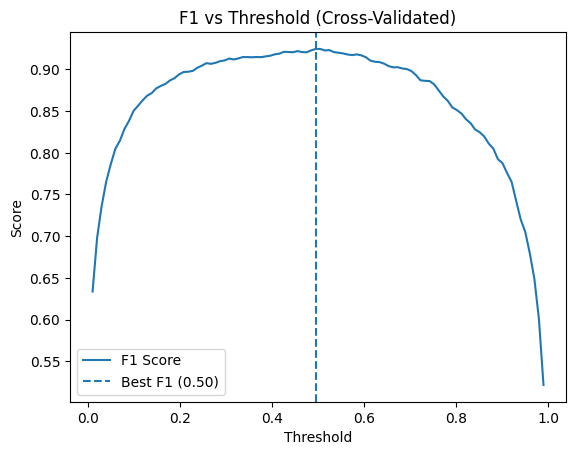

In [64]:
plt.plot(thresholds, f1_list, label="F1 Score")
plt.axvline(best_threshold, linestyle='--', label=f'Best F1 ({best_threshold:.2f})')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 vs Threshold (Cross-Validated)")
plt.legend()

plt.show()

# Model Evaluation on Labeled Data

Now that we have the thresholds, I need to compare performance on the Jigsaw evaluation subset to determine how both models perform on labeled data. The table below directly compares several performance metrics for logistic regression and Toxic-BERT. The plot below shows differences in predicted toxicity probabilities.

The code currently uses a saved cache from GitHub to reduce computation time. To run the code directly, users can change "use_saved_results = True" to False.

In [ ]:
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import warnings

from transformers import logging, pipeline

use_saved_results = True

github_url = "https://raw.githubusercontent.com/enoracat/Stats_507_Final_Project/main/bert_eval_scores.pkl"

if use_saved_results == True:
    bert_eval = pd.read_pickle(github_url)

else:
    warnings.filterwarnings("ignore")

    final_eval_df_copy = final_eval_df.copy()
    final_eval_df_copy["text"] = final_eval_df_copy["comment_text"].fillna("").astype(str)

    def score_texts(texts, batch_size=8):
        results = []
        start = time.time()

        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]

            batch_results = bert_pipe(
                batch,
                batch_size=batch_size,
                truncation=True,
                max_length=512
            )

            results.extend(batch_results)

            if i % (batch_size * 20) == 0:
                print(f"Processed {i} / {len(texts)} in {time.time() - start:.1f} seconds")

        return results

    bert_eval_results = score_texts(final_eval_df_copy["text"].tolist())

    bert_score_df = pd.DataFrame(
        [{f'bert_{item["label"]}': item["score"] for item in row} for row in bert_eval_results]
    )

    bert_eval = pd.concat([final_eval_df_copy.reset_index(drop=True), bert_score_df], axis=1)

    bert_eval.to_pickle("bert_eval_scores.pkl")

y_eval = bert_eval["toxic"].values
bert_probs = bert_eval["bert_toxic"].values
bert_pred = (bert_probs >= 0.495).astype(int)


  0%|          | 1/1250 [00:01<29:04,  1.40s/it]

Processed 0 / 10000 in 1.4 seconds


  2%|▏         | 21/1250 [00:14<09:45,  2.10it/s]

Processed 160 / 10000 in 14.1 seconds


  3%|▎         | 41/1250 [00:26<19:35,  1.03it/s]

Processed 320 / 10000 in 26.8 seconds


  5%|▍         | 61/1250 [00:40<16:25,  1.21it/s]

Processed 480 / 10000 in 40.6 seconds


  7%|▋         | 82/1250 [00:55<10:11,  1.91it/s]

Processed 640 / 10000 in 55.4 seconds


  8%|▊         | 101/1250 [01:09<13:11,  1.45it/s]

Processed 800 / 10000 in 69.1 seconds


 10%|▉         | 121/1250 [01:22<14:11,  1.33it/s]

Processed 960 / 10000 in 82.5 seconds


 11%|█▏        | 141/1250 [01:36<14:15,  1.30it/s]

Processed 1120 / 10000 in 96.7 seconds


 13%|█▎        | 161/1250 [01:47<09:05,  2.00it/s]

Processed 1280 / 10000 in 107.5 seconds


 14%|█▍        | 181/1250 [01:59<10:06,  1.76it/s]

Processed 1440 / 10000 in 119.9 seconds


 16%|█▌        | 201/1250 [02:14<15:02,  1.16it/s]

Processed 1600 / 10000 in 134.6 seconds


 18%|█▊        | 221/1250 [02:29<14:10,  1.21it/s]

Processed 1760 / 10000 in 149.4 seconds


 19%|█▉        | 241/1250 [02:41<11:23,  1.48it/s]

Processed 1920 / 10000 in 161.6 seconds


 21%|██        | 261/1250 [02:58<09:08,  1.80it/s]

Processed 2080 / 10000 in 178.4 seconds


 22%|██▏       | 281/1250 [03:12<08:20,  1.94it/s]

Processed 2240 / 10000 in 192.2 seconds


 24%|██▍       | 301/1250 [03:27<12:42,  1.25it/s]

Processed 2400 / 10000 in 207.1 seconds


 26%|██▌       | 321/1250 [03:38<08:24,  1.84it/s]

Processed 2560 / 10000 in 218.4 seconds


 27%|██▋       | 341/1250 [03:54<08:17,  1.83it/s]

Processed 2720 / 10000 in 234.5 seconds


 29%|██▉       | 362/1250 [04:07<09:13,  1.60it/s]

Processed 2880 / 10000 in 247.5 seconds


 30%|███       | 381/1250 [04:19<11:12,  1.29it/s]

Processed 3040 / 10000 in 259.1 seconds


 32%|███▏      | 401/1250 [04:32<07:42,  1.84it/s]

Processed 3200 / 10000 in 272.8 seconds


 34%|███▎      | 421/1250 [04:47<09:45,  1.42it/s]

Processed 3360 / 10000 in 287.3 seconds


 35%|███▌      | 441/1250 [05:02<10:37,  1.27it/s]

Processed 3520 / 10000 in 302.1 seconds


 37%|███▋      | 461/1250 [05:17<10:44,  1.22it/s]

Processed 3680 / 10000 in 317.2 seconds


 38%|███▊      | 481/1250 [05:33<11:24,  1.12it/s]

Processed 3840 / 10000 in 333.2 seconds


 40%|████      | 501/1250 [05:45<05:25,  2.30it/s]

Processed 4000 / 10000 in 345.5 seconds


 42%|████▏     | 521/1250 [05:56<04:57,  2.45it/s]

Processed 4160 / 10000 in 356.6 seconds


 43%|████▎     | 541/1250 [06:09<07:16,  1.63it/s]

Processed 4320 / 10000 in 369.4 seconds


 45%|████▍     | 562/1250 [06:26<08:02,  1.43it/s]

Processed 4480 / 10000 in 385.9 seconds


 46%|████▋     | 581/1250 [06:40<09:33,  1.17it/s]

Processed 4640 / 10000 in 400.8 seconds


 48%|████▊     | 601/1250 [06:52<06:51,  1.58it/s]

Processed 4800 / 10000 in 412.2 seconds


 50%|████▉     | 621/1250 [07:02<05:26,  1.92it/s]

Processed 4960 / 10000 in 422.6 seconds


 51%|█████▏    | 641/1250 [07:18<07:12,  1.41it/s]

Processed 5120 / 10000 in 438.2 seconds


 53%|█████▎    | 661/1250 [07:32<09:03,  1.08it/s]

Processed 5280 / 10000 in 452.6 seconds


 54%|█████▍    | 681/1250 [07:44<04:30,  2.10it/s]

Processed 5440 / 10000 in 464.5 seconds


 56%|█████▌    | 701/1250 [07:58<06:22,  1.44it/s]

Processed 5600 / 10000 in 478.5 seconds


 58%|█████▊    | 721/1250 [08:10<03:43,  2.37it/s]

Processed 5760 / 10000 in 490.0 seconds


 59%|█████▉    | 741/1250 [08:25<04:19,  1.96it/s]

Processed 5920 / 10000 in 505.6 seconds


 61%|██████    | 761/1250 [08:40<05:51,  1.39it/s]

Processed 6080 / 10000 in 520.6 seconds


 62%|██████▏   | 781/1250 [08:54<06:55,  1.13it/s]

Processed 6240 / 10000 in 534.8 seconds


 64%|██████▍   | 801/1250 [09:07<07:15,  1.03it/s]

Processed 6400 / 10000 in 547.2 seconds


 66%|██████▌   | 822/1250 [09:22<03:33,  2.00it/s]

Processed 6560 / 10000 in 562.2 seconds


 67%|██████▋   | 841/1250 [09:34<04:41,  1.45it/s]

Processed 6720 / 10000 in 574.6 seconds


 69%|██████▉   | 861/1250 [09:44<02:45,  2.36it/s]

Processed 6880 / 10000 in 584.1 seconds


 70%|███████   | 881/1250 [09:58<05:11,  1.18it/s]

Processed 7040 / 10000 in 598.2 seconds


 72%|███████▏  | 901/1250 [10:10<03:21,  1.73it/s]

Processed 7200 / 10000 in 610.7 seconds


 74%|███████▎  | 921/1250 [10:27<05:10,  1.06it/s]

Processed 7360 / 10000 in 627.4 seconds


 75%|███████▌  | 941/1250 [10:40<02:54,  1.77it/s]

Processed 7520 / 10000 in 640.3 seconds


 77%|███████▋  | 961/1250 [10:54<03:16,  1.47it/s]

Processed 7680 / 10000 in 654.8 seconds


 79%|███████▊  | 982/1250 [11:09<02:12,  2.03it/s]

Processed 7840 / 10000 in 669.4 seconds


 80%|████████  | 1001/1250 [11:26<04:11,  1.01s/it]

Processed 8000 / 10000 in 686.4 seconds


 82%|████████▏ | 1021/1250 [11:42<04:01,  1.05s/it]

Processed 8160 / 10000 in 702.8 seconds


 83%|████████▎ | 1041/1250 [11:59<02:38,  1.32it/s]

Processed 8320 / 10000 in 719.7 seconds


 85%|████████▍ | 1061/1250 [12:11<01:32,  2.04it/s]

Processed 8480 / 10000 in 731.8 seconds


 86%|████████▋ | 1081/1250 [12:24<01:41,  1.67it/s]

Processed 8640 / 10000 in 744.8 seconds


 88%|████████▊ | 1101/1250 [12:37<01:03,  2.33it/s]

Processed 8800 / 10000 in 757.3 seconds


 90%|████████▉ | 1121/1250 [12:51<01:29,  1.44it/s]

Processed 8960 / 10000 in 771.5 seconds


 91%|█████████▏| 1141/1250 [13:03<01:07,  1.62it/s]

Processed 9120 / 10000 in 783.7 seconds


 93%|█████████▎| 1161/1250 [13:19<01:27,  1.02it/s]

Processed 9280 / 10000 in 799.5 seconds


 94%|█████████▍| 1181/1250 [13:31<00:49,  1.40it/s]

Processed 9440 / 10000 in 812.0 seconds


 96%|█████████▌| 1201/1250 [13:46<00:28,  1.69it/s]

Processed 9600 / 10000 in 826.6 seconds


 98%|█████████▊| 1221/1250 [14:02<00:14,  2.02it/s]

Processed 9760 / 10000 in 842.6 seconds


 99%|█████████▉| 1241/1250 [14:18<00:04,  2.08it/s]

Processed 9920 / 10000 in 858.1 seconds


100%|██████████| 1250/1250 [14:25<00:00,  1.44it/s]


In [66]:
X_eval = final_eval_df["comment_text"].fillna("").astype(str)
y_eval = final_eval_df["toxic"].values

logreg_probs = pipeline_logistic.predict_proba(X_eval)[:, 1]
logreg_pred = (logreg_probs >= .77).astype(int)

In [67]:
results_compare = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC_AUC": roc_auc_score(y_eval, logreg_probs),
        "Precision": precision_score(y_eval, logreg_pred),
        "Recall": recall_score(y_eval, logreg_pred),
        "F1": f1_score(y_eval, logreg_pred)
    },
    {
        "Model": "Toxic-BERT",
        "ROC_AUC": roc_auc_score(y_eval, bert_probs),
        "Precision": precision_score(y_eval, bert_pred),
        "Recall": recall_score(y_eval, bert_pred),
        "F1": f1_score(y_eval, bert_pred)
    }
])

results_compare

,Model,ROC_AUC,Precision,Recall,F1
0,Logistic Regression,0.965101,0.814469,0.728601,0.769146
1,Toxic-BERT,0.997615,0.919087,0.924843,0.921956


In [68]:
eval_compare = pd.DataFrame({
    "true": y_eval,
    "logreg_prob": logreg_probs,
    "logreg_pred": logreg_pred,
    "bert_prob": bert_probs,
    "bert_pred": bert_pred
})


(eval_compare["logreg_pred"] != eval_compare["bert_pred"]).mean()

np.float64(0.0391)

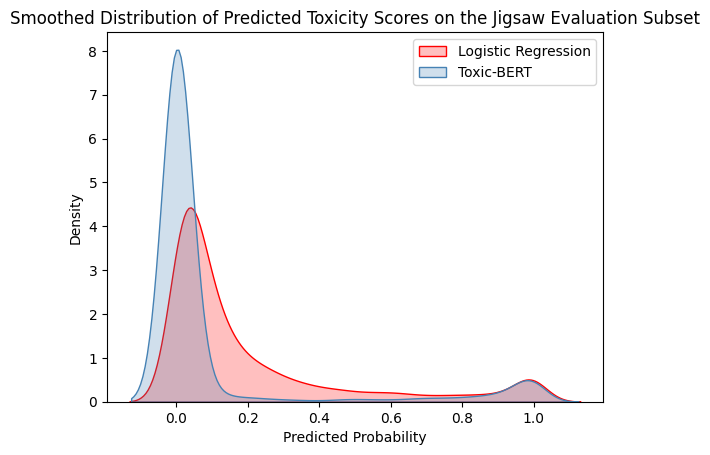

In [69]:
sns.kdeplot(eval_compare["logreg_prob"], label="Logistic Regression", fill=True, color = "r")
sns.kdeplot(eval_compare["bert_prob"], label="Toxic-BERT", fill=True, color = "steelblue")

plt.xlabel("Predicted Probability")
plt.title("Smoothed Distribution of Predicted Toxicity Scores on the Jigsaw Evaluation Subset")
plt.legend()
plt.show()

# Reddit Data Analysis

Before beginning analysis, we need to load the data. The dataset was originally obtained from HuggingFace: https://huggingface.co/datasets/mo-mittal/reddit_political_subs and contains 7,503 posts from several political subreddits.

However, it requires an old version of the datasets package to access directly via HuggingFace, so I have uploaded it to Github to avoid package version issues when accessing the data.

In [70]:
url = "https://raw.githubusercontent.com/enoracat/Stats_507_Final_Project/main/reddit_political_subs_dataset.csv"
df = pd.read_csv(url)

df.head()

,Unnamed: 0,author,created_utc,domain,title,selftext,subreddit,score,num_comments,ups,...,url,subreddit_subscribers,upvote_ratio,is_original_content,media,selftext_html,author_flair_text,link_flair_text,image,image_text
0,0,FemShep_BestShep,2014-11-30 20:31:48,i.imgur.com,President Obama has achieved incredible progress for the United States.,NaN,democrats,199,58,199.0,...,https://i.imgur.com/U01V6i7.png,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'https://i.imgur.com/U01V6i7.png'}",NaN
1,1,[deleted],2014-03-12 13:03:03,i.imgur.com,"As a self employed person, this is what ObamaCare has meant for my family.",NaN,democrats,194,31,194.0,...,http://i.imgur.com/vCQdMUw.jpg,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'http://i.imgur.com/vCQdMUw.jpg'}",NaN
2,2,Carmac,2014-11-10 15:16:55,lovebscott.com,Rolling Stone Names President Obama ‘One of the Most Successful Presidents in American History’,NaN,democrats,151,16,151.0,...,http://www.lovebscott.com/news/rolling-stone-names-president-obama-one-of-the-most-successful-presidents-in-american-history,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'http://www.lovebscott.com/news/rolling-stone-names-president-obama-one-of-the-most-successful-presidents-in-american-history'}",news rolling stone names president obama one successful presidents american history
3,3,Albert_Flasher,2014-12-25 12:21:44,i.imgur.com,Happy Holidays!,NaN,democrats,146,22,146.0,...,http://i.imgur.com/y1lOJlS.jpg,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'http://i.imgur.com/y1lOJlS.jpg'}",NaN
4,4,papepipo,2014-05-21 17:49:30,ofa.barackobama.com,"Obama identifies 150 members of congress who deny climate change, despite the clear scientific consensus, including Rand Paul, Paul Ryan, John Boehner, Ted Cruz. ""Its time to call them out,"" he says",NaN,democrats,142,6,142.0,...,http://ofa.barackobama.com/climate-deniers/#/,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'http://ofa.barackobama.com/climate-deniers/#/'}",climate deniers


As shown in the plot below, posts are evenly distributed from 9 subreddits

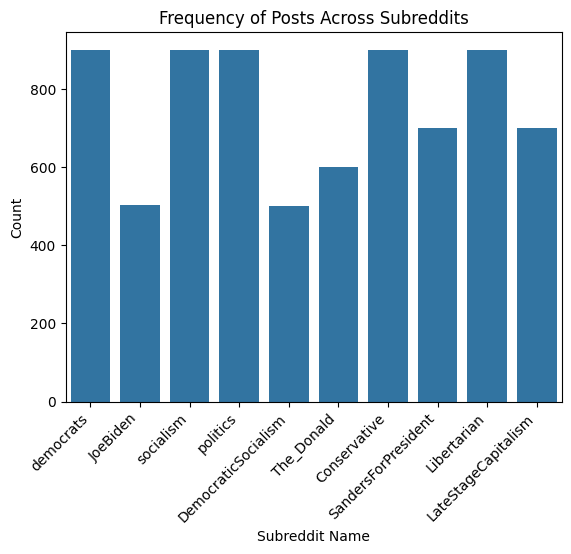

In [71]:
fig1 = sns.countplot(data=df, x = 'subreddit')
fig1.set(xlabel='Subreddit Name', ylabel = 'Count', title='Frequency of Posts Across Subreddits')
plt.xticks(rotation=45, ha='right')
plt.show()

I will start by evaluating the Reddit data with logistic regression

In [72]:
titles = df['title'].fillna('').astype(str)
probs = pipeline_logistic.predict_proba(titles)[:, 1]

df['logreg_prob'] = probs
df['logreg_pred'] = (probs >= 0.77).astype(int)

desc_stats_logreg = df['logreg_prob'].describe()
n_toxic_logreg = df['logreg_pred'].sum()
prop_toxic_logreg = df['logreg_pred'].mean()

print("Logistic Regression Probability and Classification Summary")
print(desc_stats_logreg.to_frame(name="logred_prob").round(4))
print("Number labeled toxic:", n_toxic_logreg)
print("Proportion labeled toxic:", prop_toxic_logreg)

Logistic Regression Probability and Classification Summary
       logred_prob
count    7503.0000
mean        0.2785
std         0.2185
min         0.0022
25%         0.1222
50%         0.2195
75%         0.3607
max         1.0000
Number labeled toxic: 365
Proportion labeled toxic: 0.04864720778355325


In [73]:
df['logreg_pred_oldthresh'] = (probs >= 0.5).astype(int)

n_toxic_logreg_oldthresh = df['logreg_pred_oldthresh'].sum()
prop_toxic_logreg_oldthresh = df['logreg_pred_oldthresh'].mean()

print("Logistic Regression Classification Summary at Old Threshold (0.5)")
print("Number labeled toxic:", n_toxic_logreg_oldthresh)
print("Proportion labeled toxic:", prop_toxic_logreg_oldthresh)

Logistic Regression Classification Summary at Old Threshold (0.5)
Number labeled toxic: 1102
Proportion labeled toxic: 0.14687458349993335


Now evaluating the Reddit data with Toxic-BERT

The code currently uses a saved cache from GitHub to reduce computation time. To run the code directly, users can change "use_saved_results = True" to False.

In [ ]:
use_saved_results = True

github_url = "https://raw.githubusercontent.com/enoracat/Stats_507_Final_Project/main/bert_toxicity_df.pkl"

if use_saved_results == True:
    bert_reddit = pd.read_pickle(github_url)
    
else:
    warnings.filterwarnings("ignore")

    df = df.copy()
    df["text"] = df["title"].fillna("").astype(str)

    def score_texts(texts, batch_size=8):
        results = []
        start = time.time()

        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            batch_results = bert_pipe(batch, batch_size=batch_size, truncation=True, max_length=512)
            results.extend(batch_results)

            if i % (batch_size * 20) == 0:
                print(f"Processed {i} / {len(texts)} in {time.time() - start:.1f} seconds")

        return results

    reddit_bert_toxicity = score_texts(df["text"].tolist())

    bert_score_df = pd.DataFrame(
        [{item["label"]: item["score"] for item in row} for row in reddit_bert_toxicity]
    )


    bert_toxicity_df = pd.concat([df.reset_index(drop=True), bert_score_df], axis=1)
    
    bert_toxicity_df.to_pickle("bert_toxicity_df.pkl")

    bert_reddit = bert_toxicity_df

df['bert_prob'] = bert_reddit['toxic']
df['bert_pred'] = (bert_reddit['toxic'] >= 0.495).astype(int)

desc_stats_bert = df['bert_prob'].describe()
n_toxic_bert = df['bert_pred'].sum()
prop_toxic_bert = df['bert_pred'].mean()

print("Toxic-BERT Probability and Classification Summary")
print(desc_stats_bert.to_frame(name="bert_prob").round(4))
print("Number labeled toxic:", n_toxic_bert)
print("Proportion labeled toxic:", prop_toxic_bert)

  0%|          | 1/938 [00:00<01:44,  8.99it/s]

Processed 0 / 7503 in 0.1 seconds


  2%|▏         | 22/938 [00:02<02:04,  7.34it/s]

Processed 160 / 7503 in 2.8 seconds


  4%|▍         | 42/938 [00:05<01:50,  8.12it/s]

Processed 320 / 7503 in 5.4 seconds


  7%|▋         | 62/938 [00:08<02:00,  7.25it/s]

Processed 480 / 7503 in 7.9 seconds


  9%|▊         | 81/938 [00:10<01:22, 10.40it/s]

Processed 640 / 7503 in 10.7 seconds


 11%|█         | 102/938 [00:12<01:12, 11.54it/s]

Processed 800 / 7503 in 12.8 seconds


 13%|█▎        | 124/938 [00:14<00:57, 14.14it/s]

Processed 960 / 7503 in 14.5 seconds


 15%|█▌        | 141/938 [00:16<01:53,  7.00it/s]

Processed 1120 / 7503 in 16.9 seconds


 17%|█▋        | 163/938 [00:19<01:04, 11.97it/s]

Processed 1280 / 7503 in 18.9 seconds


 20%|█▉        | 183/938 [00:21<01:14, 10.20it/s]

Processed 1440 / 7503 in 20.9 seconds


 22%|██▏       | 202/938 [00:23<01:15,  9.77it/s]

Processed 1600 / 7503 in 23.0 seconds


 24%|██▎       | 222/938 [00:25<01:06, 10.74it/s]

Processed 1760 / 7503 in 25.0 seconds


 26%|██▌       | 242/938 [00:27<01:10,  9.83it/s]

Processed 1920 / 7503 in 27.0 seconds


 28%|██▊       | 262/938 [00:29<01:10,  9.54it/s]

Processed 2080 / 7503 in 29.0 seconds


 30%|███       | 282/938 [00:31<01:16,  8.62it/s]

Processed 2240 / 7503 in 31.0 seconds


 32%|███▏      | 302/938 [00:33<01:22,  7.67it/s]

Processed 2400 / 7503 in 33.7 seconds


 34%|███▍      | 323/938 [00:36<00:44, 13.86it/s]

Processed 2560 / 7503 in 36.0 seconds


 37%|███▋      | 343/938 [00:37<00:45, 13.00it/s]

Processed 2720 / 7503 in 37.4 seconds


 38%|███▊      | 361/938 [00:38<00:48, 11.96it/s]

Processed 2880 / 7503 in 39.0 seconds


 41%|████      | 382/938 [00:41<00:55, 10.00it/s]

Processed 3040 / 7503 in 41.1 seconds


 43%|████▎     | 402/938 [00:43<01:02,  8.60it/s]

Processed 3200 / 7503 in 43.0 seconds


 45%|████▍     | 421/938 [00:45<00:41, 12.45it/s]

Processed 3360 / 7503 in 45.5 seconds


 47%|████▋     | 443/938 [00:47<00:43, 11.33it/s]

Processed 3520 / 7503 in 47.2 seconds


 49%|████▉     | 464/938 [00:48<00:32, 14.70it/s]

Processed 3680 / 7503 in 48.5 seconds


 51%|█████▏    | 481/938 [00:50<00:52,  8.71it/s]

Processed 3840 / 7503 in 50.5 seconds


 54%|█████▎    | 502/938 [00:53<01:00,  7.26it/s]

Processed 4000 / 7503 in 52.9 seconds


 56%|█████▌    | 522/938 [00:55<00:48,  8.53it/s]

Processed 4160 / 7503 in 55.4 seconds


 58%|█████▊    | 541/938 [00:57<00:31, 12.41it/s]

Processed 4320 / 7503 in 57.6 seconds


 60%|█████▉    | 561/938 [00:59<00:33, 11.22it/s]

Processed 4480 / 7503 in 59.4 seconds


 62%|██████▏   | 581/938 [01:01<00:30, 11.61it/s]

Processed 4640 / 7503 in 61.2 seconds


 64%|██████▍   | 604/938 [01:02<00:22, 14.93it/s]

Processed 4800 / 7503 in 62.8 seconds


 66%|██████▋   | 623/938 [01:04<00:25, 12.17it/s]

Processed 4960 / 7503 in 64.2 seconds


 69%|██████▊   | 643/938 [01:06<00:25, 11.44it/s]

Processed 5120 / 7503 in 66.1 seconds


 71%|███████   | 662/938 [01:08<00:33,  8.27it/s]

Processed 5280 / 7503 in 68.2 seconds


 73%|███████▎  | 682/938 [01:10<00:32,  7.86it/s]

Processed 5440 / 7503 in 70.8 seconds


 75%|███████▍  | 702/938 [01:13<00:31,  7.51it/s]

Processed 5600 / 7503 in 73.3 seconds


 77%|███████▋  | 722/938 [01:16<00:27,  8.00it/s]

Processed 5760 / 7503 in 76.3 seconds


 79%|███████▉  | 742/938 [01:18<00:22,  8.62it/s]

Processed 5920 / 7503 in 78.5 seconds


 81%|████████  | 762/938 [01:21<00:22,  7.79it/s]

Processed 6080 / 7503 in 81.0 seconds


 83%|████████▎ | 783/938 [01:23<00:13, 11.43it/s]

Processed 6240 / 7503 in 83.3 seconds


 86%|████████▌ | 802/938 [01:25<00:11, 11.83it/s]

Processed 6400 / 7503 in 84.9 seconds


 88%|████████▊ | 822/938 [01:27<00:13,  8.59it/s]

Processed 6560 / 7503 in 87.1 seconds


 90%|████████▉ | 842/938 [01:29<00:12,  7.51it/s]

Processed 6720 / 7503 in 89.7 seconds


 92%|█████████▏| 861/938 [01:31<00:07, 10.33it/s]

Processed 6880 / 7503 in 91.7 seconds


 94%|█████████▍| 883/938 [01:33<00:04, 11.42it/s]

Processed 7040 / 7503 in 93.5 seconds


 96%|█████████▋| 904/938 [01:35<00:02, 15.82it/s]

Processed 7200 / 7503 in 95.0 seconds


 98%|█████████▊| 923/938 [01:36<00:00, 19.09it/s]

Processed 7360 / 7503 in 96.1 seconds


100%|██████████| 938/938 [01:36<00:00,  9.68it/s]


Toxic-BERT Probability and Classification Summary
       bert_prob
count  7503.0000
mean      0.0606
std       0.1846
min       0.0005
25%       0.0008
50%       0.0015
75%       0.0115
max       0.9989
Number labeled toxic: 372
Proportion labeled toxic: 0.04958016793282687


The plot below shows differences in the distributions of predicted probabilities

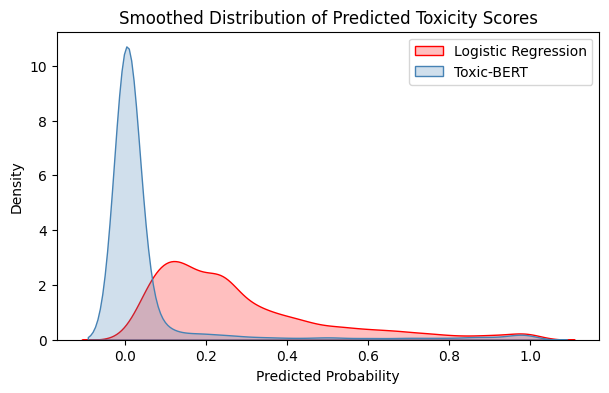

In [75]:
plt.figure(figsize=(7, 4))

sns.kdeplot(df["logreg_prob"], label="Logistic Regression", fill=True, color = "r")
sns.kdeplot(df["bert_prob"], label="Toxic-BERT", fill=True, color = "steelblue")

plt.xlabel("Predicted Probability")
plt.title("Smoothed Distribution of Predicted Toxicity Scores")
plt.legend()
plt.show()

Assessing disagreement in classification between logistic regression and Toxic-BERT

In [76]:
pd.crosstab(
    df['logreg_pred'],
    df['bert_pred'],
    rownames=['LogReg'],
    colnames=['BERT']
)

BERT,0,1
LogReg,,
0,6981,157
1,150,215


To understand why the models are creating different predictions, it is useful to look at some of the observations which they disagreed on

In [77]:
pd.set_option('display.max_colwidth', None)
df.loc[df['logreg_pred'] != df['bert_pred'], ['title', 'logreg_prob', 'bert_prob']].head(30)

,title,logreg_prob,bert_prob
7,Memo to Dick Cheney: George Washington ordered execution as penalty for torturing prisoners,0.916560,0.030690
27,"Jon Stewart on Fox's 'Latte Salute' Coverage: ""F**k You All &amp; Your False Patriotism""",0.361937,0.959717
30,Republicans Finally Admit There's No Benghazi Scandal,0.791122,0.011497
50,"Yes, Dick Cheney is lying when he claims that Obama dropped Bush’s missile defense plan after a ‘mere request’ from Putin",0.794298,0.036982
53,Bill Nye tells Bill Maher: America can’t afford a generation of ‘scientifically illiterate’ children,0.161562,0.573710
62,"Christie Says, ""I Am Not a Bully."" Here Are 8 Videos of Him Yelling, Name-Calling, and Belittling People. - ""Something may be going down, but it ain't going to be jobs sweetheart.""",0.780670,0.014459
70,"Nevada rancher is just a welfare cowboy: ""He’s no hero. He’s a deadbeat. A moocher, flouting laws and bilking the taxpayer while law-abiding citizens pay their bills""",0.186136,0.631562
102,"Yes, The Planned Parenthood Shooter Is A ‘Christian Terrorist’",0.267092,0.587295
142,"Bernie Sanders is officially running. We complain about how awful Republicans are, we complain that Democrats just aren't doing enough. This page says enough.",0.789365,0.159657
146,John Oliver rips America’s disgraceful maternity leave policy: Thanks for giving us life — “now get the f*ck back to work” - The U.S. is 1 of only 2 countries in the world that doesn't offer paid time off to new mothers,0.600620,0.887475


We can also visualize the disagreement at the level of individual posts

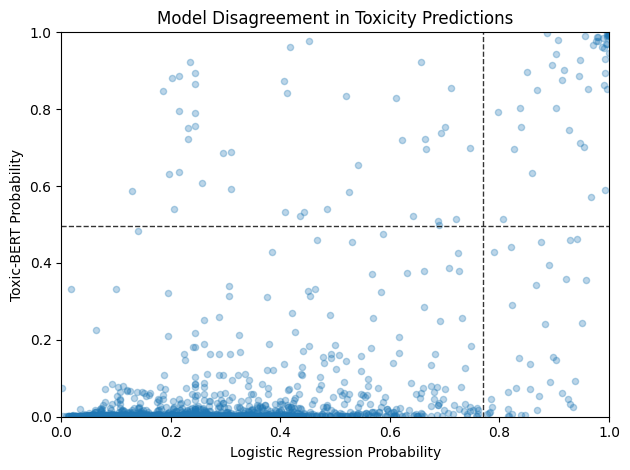

In [78]:
df_sample = df.sample(n=2000, random_state=1)

plt.scatter(
    df_sample["logreg_prob"],
    df_sample["bert_prob"],
    alpha=0.3,
    s = 20
)

plt.axvline(0.77, color="black", linestyle="--", linewidth=1, alpha = 0.8)
plt.axhline(0.495, color="blacK", linestyle="--", linewidth=1, alpha = 0.8)

plt.xlabel("Logistic Regression Probability")
plt.ylabel("Toxic-BERT Probability")
plt.title("Model Disagreement in Toxicity Predictions")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

After considering disagreement overall, it is also useful to consider if disagreement varies by specific post features: 1. Subreddit, 2. post length, and 3. post score

First looking at subreddit

In [79]:
df['disagree'] = (df['logreg_pred'] != df['bert_pred']).astype(int)

subreddit_toxic = df.groupby('subreddit').agg(
    logreg_toxic_rate=('logreg_pred', 'mean'),
    bert_toxic_rate=('bert_pred', 'mean'),
    disagreement_rate=('disagree', 'mean'),
    n_posts=('title', 'size')
).reset_index()

subreddit_toxic['toxicity_diff'] = (
    subreddit_toxic['logreg_toxic_rate'] - subreddit_toxic['bert_toxic_rate']
)

print("Subreddit Toxicity Comparison")
print(
    subreddit_toxic
    .round(4)
    .to_string(index=False)
)

Subreddit Toxicity Comparison
          subreddit  logreg_toxic_rate  bert_toxic_rate  disagreement_rate  n_posts  toxicity_diff
       Conservative             0.0533           0.0467             0.0356      900         0.0067
DemocraticSocialism             0.0360           0.0440             0.0360      500        -0.0080
           JoeBiden             0.0338           0.0318             0.0219      503         0.0020
LateStageCapitalism             0.0657           0.0686             0.0457      700        -0.0029
        Libertarian             0.0456           0.0544             0.0444      900        -0.0089
SandersForPresident             0.0171           0.0171             0.0200      700         0.0000
         The_Donald             0.0867           0.1033             0.0633      600        -0.0167
          democrats             0.0533           0.0556             0.0556      900        -0.0022
           politics             0.0389           0.0222             0.0367     

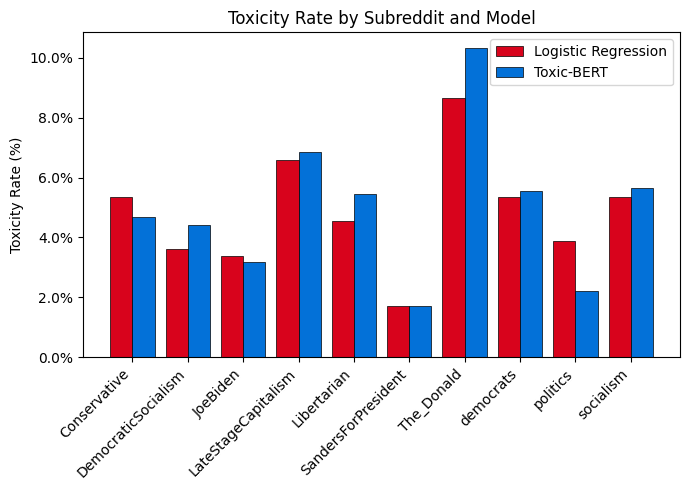

In [80]:
subs = subreddit_toxic['subreddit']
x = np.arange(len(subs))

plt.figure(figsize=(7, 5))

plt.bar(x - 0.2, subreddit_toxic['logreg_toxic_rate'], width=0.4,
        label='Logistic Regression', color='#d8031c', edgecolor='black', linewidth=0.5)
plt.bar(x + 0.2, subreddit_toxic['bert_toxic_rate'], width=0.4,
        label='Toxic-BERT', color='#0371d8', edgecolor='black', linewidth=0.5)

plt.xticks(x, subs, rotation=45, ha='right')
plt.ylabel('Toxicity Rate (%)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Toxicity Rate by Subreddit and Model')
plt.legend()

plt.tight_layout()
plt.savefig('subreddit_toxic.png', dpi=300, bbox_inches='tight')
plt.show()

Now moving to post length

In [81]:
df['word_count'] = df['title'].str.split().str.len()
df['prob_diff'] = df['bert_prob'] - df['logreg_prob']

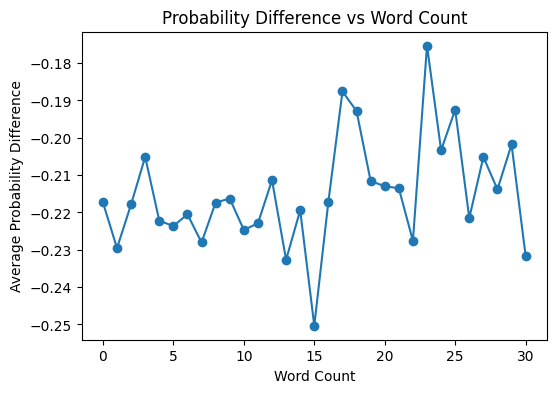

In [82]:
df['length_bin'] = pd.qcut(df['word_count'], 60, duplicates='drop')

score_summary = df.groupby('length_bin', observed=True)['prob_diff'].mean()

plt.figure(figsize=(6,4))
plt.plot(range(len(score_summary)), score_summary.values, marker='o')
plt.xlabel('Word Count')
plt.ylabel('Average Probability Difference')
plt.title('Probability Difference vs Word Count')
plt.show()

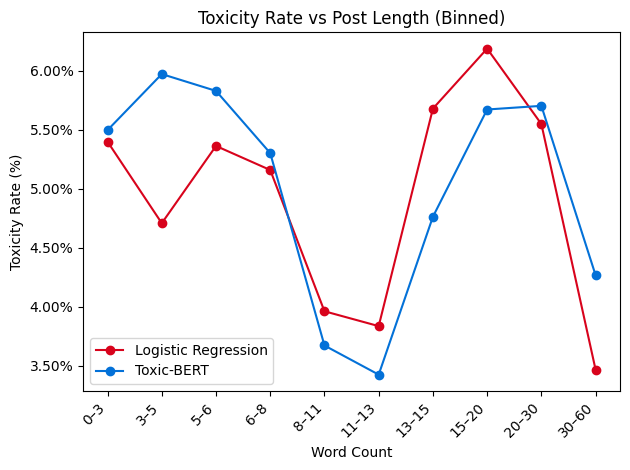

In [83]:
df['length_bin'] = pd.qcut(df['word_count'], q=10, duplicates='drop')

length_plot = df.groupby('length_bin', observed=False).agg(
    logreg_toxic_rate=('logreg_pred', 'mean'),
    bert_toxic_rate=('bert_pred', 'mean')
).reset_index()

length_plot['bin_label'] = length_plot['length_bin'].apply(
    lambda x: f"{int(x.left)}–{int(x.right)}"
)

plt.plot(length_plot['bin_label'], length_plot['logreg_toxic_rate'],
         marker='o', label='Logistic Regression', color='#d8031c')

plt.plot(length_plot['bin_label'], length_plot['bert_toxic_rate'],
         marker='o', label='Toxic-BERT', color='#0371d8')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Toxicity Rate (%)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel('Word Count')
plt.title('Toxicity Rate vs Post Length (Binned)')
plt.legend()

plt.tight_layout()
plt.show()

Finally looking at post score

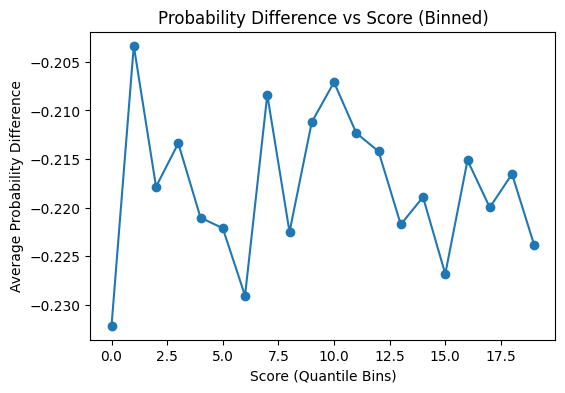

In [84]:
df['score_bin'] = pd.qcut(df['score'], 20, duplicates='drop')

score_summary = df.groupby('score_bin', observed=True)['prob_diff'].mean()

plt.figure(figsize=(6,4))
plt.plot(range(len(score_summary)), score_summary.values, marker='o')
plt.xlabel('Score (Quantile Bins)')
plt.ylabel('Average Probability Difference')
plt.title('Probability Difference vs Score (Binned)')
plt.show()

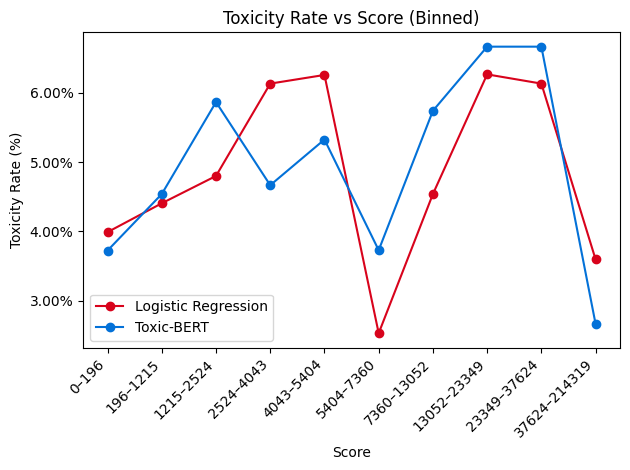

In [85]:
df['score_bin'] = pd.qcut(df['score'], q=10, duplicates='drop')

score_plot = df.groupby('score_bin', observed=False).agg(
    logreg_toxic_rate=('logreg_pred', 'mean'),
    bert_toxic_rate=('bert_pred', 'mean')
).reset_index()

score_plot['bin_label'] = score_plot['score_bin'].apply(
    lambda x: f"{int(x.left)}–{int(x.right)}"
)

plt.plot(score_plot['bin_label'], score_plot['logreg_toxic_rate'],
         marker='o', label='Logistic Regression', color='#d8031c')

plt.plot(score_plot['bin_label'], score_plot['bert_toxic_rate'],
         marker='o', label='Toxic-BERT', color='#0371d8')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Toxicity Rate (%)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel('Score')
plt.title('Toxicity Rate vs Score (Binned)')
plt.legend()

plt.tight_layout()
plt.show()